CODE USED TO GENERATE FIGURE 1 IN RESEARCH PAPER

Imports

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.gridspec as gridspec
from IPython.display import display, clear_output
import duckdb

Display Settings

In [2]:
pd.set_option('display.max_rows', 10)
pd.set_option('display.float_format', '{:.5f}'.format)

In [3]:
query = f"""
SELECT * 
FROM 'spy_mbo/processed/spy_mbo.parquet'
WHERE ts_event >= '2026-03-23 10:00:00' AND ts_event <= '2026-03-23 10:30:00'
"""
market_by_order_data_df = duckdb.sql(query).df()
market_by_order_data_df

,ts_event,rtype,publisher_id,instrument_id,action,side,price,size,channel_id,order_id,flags,ts_in_delta,sequence,symbol,ts_recv
0,2026-03-23 10:00:00.000344-04:00,160,43,15144,A,B,660.19000,18,0,284773571068696,128,199366,23939758,SPY,2026-03-23 10:00:00.000551-04:00
1,2026-03-23 10:00:00.000353-04:00,160,43,15144,A,A,660.23000,16,0,284773571068705,128,199407,23939759,SPY,2026-03-23 10:00:00.000560-04:00
2,2026-03-23 10:00:00.000560-04:00,160,5,15144,A,A,660.23000,80,23,3191404863773174854,128,32762,21228992,SPY,2026-03-23 10:00:00.000592-04:00
3,2026-03-23 10:00:00.000572-04:00,160,15,15144,A,A,660.23000,80,0,860838092,128,0,105650931,SPY,2026-03-23 10:00:00.000584-04:00
4,2026-03-23 10:00:00.000624-04:00,160,2,15144,T,A,660.20000,100,0,0,0,166466,305195009,SPY,2026-03-23 10:00:00.000791-04:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9752969,2026-03-23 10:29:59.990853-04:00,160,2,15144,C,B,660.98000,40,0,819098584,128,162881,439257443,SPY,2026-03-23 10:29:59.991016-04:00
9752970,2026-03-23 10:29:59.990983-04:00,160,8,15144,C,B,660.98000,40,23,3191404932498824872,128,27555,27322436,SPY,2026-03-23 10:29:59.991010-04:00
9752971,2026-03-23 10:29:59.990985-04:00,160,5,15144,C,B,660.98000,40,23,3191404863781869157,128,27343,29010720,SPY,2026-03-23 10:29:59.991012-04:00
9752972,2026-03-23 10:29:59.991034-04:00,160,5,15144,C,B,660.98000,10,23,3191404863781869158,128,29522,29010721,SPY,2026-03-23 10:29:59.991063-04:00


Limit Order Book Historical Replay

In [4]:
# exchange mapping from publisher_id to the exchange description and exchange identification code
exchange_mapping = {
    2: 'Nasdaq (XNAS)',
    3: 'Nasdaq Texas (XBOS)',
    4: 'Nasdaq PSX (XPSX)',
    5: 'Cboe BZX (BATS)',
    6: 'Cboe BYX (BATY)',
    7: 'Cboe EDGA (EDGA)',
    8: 'Cboe EDGX (EDGX)',
    9: 'NYSE (XNYS)',
    11: 'NYSE American (XASE)',
    12: 'NYSE Texas (XCHI)',
    15: 'MEMX MEMOIR (MEMX)',
    16: 'MIAX Pearl (EPRL)',
    43: 'NYSE Arca (ARCX)'
}

In [5]:
# dictionary holding bid and ask limit order queues at each price for all 14 exchanges
publisher_id_list = market_by_order_data_df['publisher_id'].unique()
bids = {publisher_id: {} for publisher_id in publisher_id_list}
asks = {publisher_id: {} for publisher_id in publisher_id_list}

# master tracker of all orders processed from the market by order feed consolidated across all 14 exchanges
# global_id -> {publisher_id, side, price}
order_tracker = {}

# counts the number of orders processed by each of the 14 exchanges 
order_processed_map = {publisher_id: 0 for publisher_id in publisher_id_list}

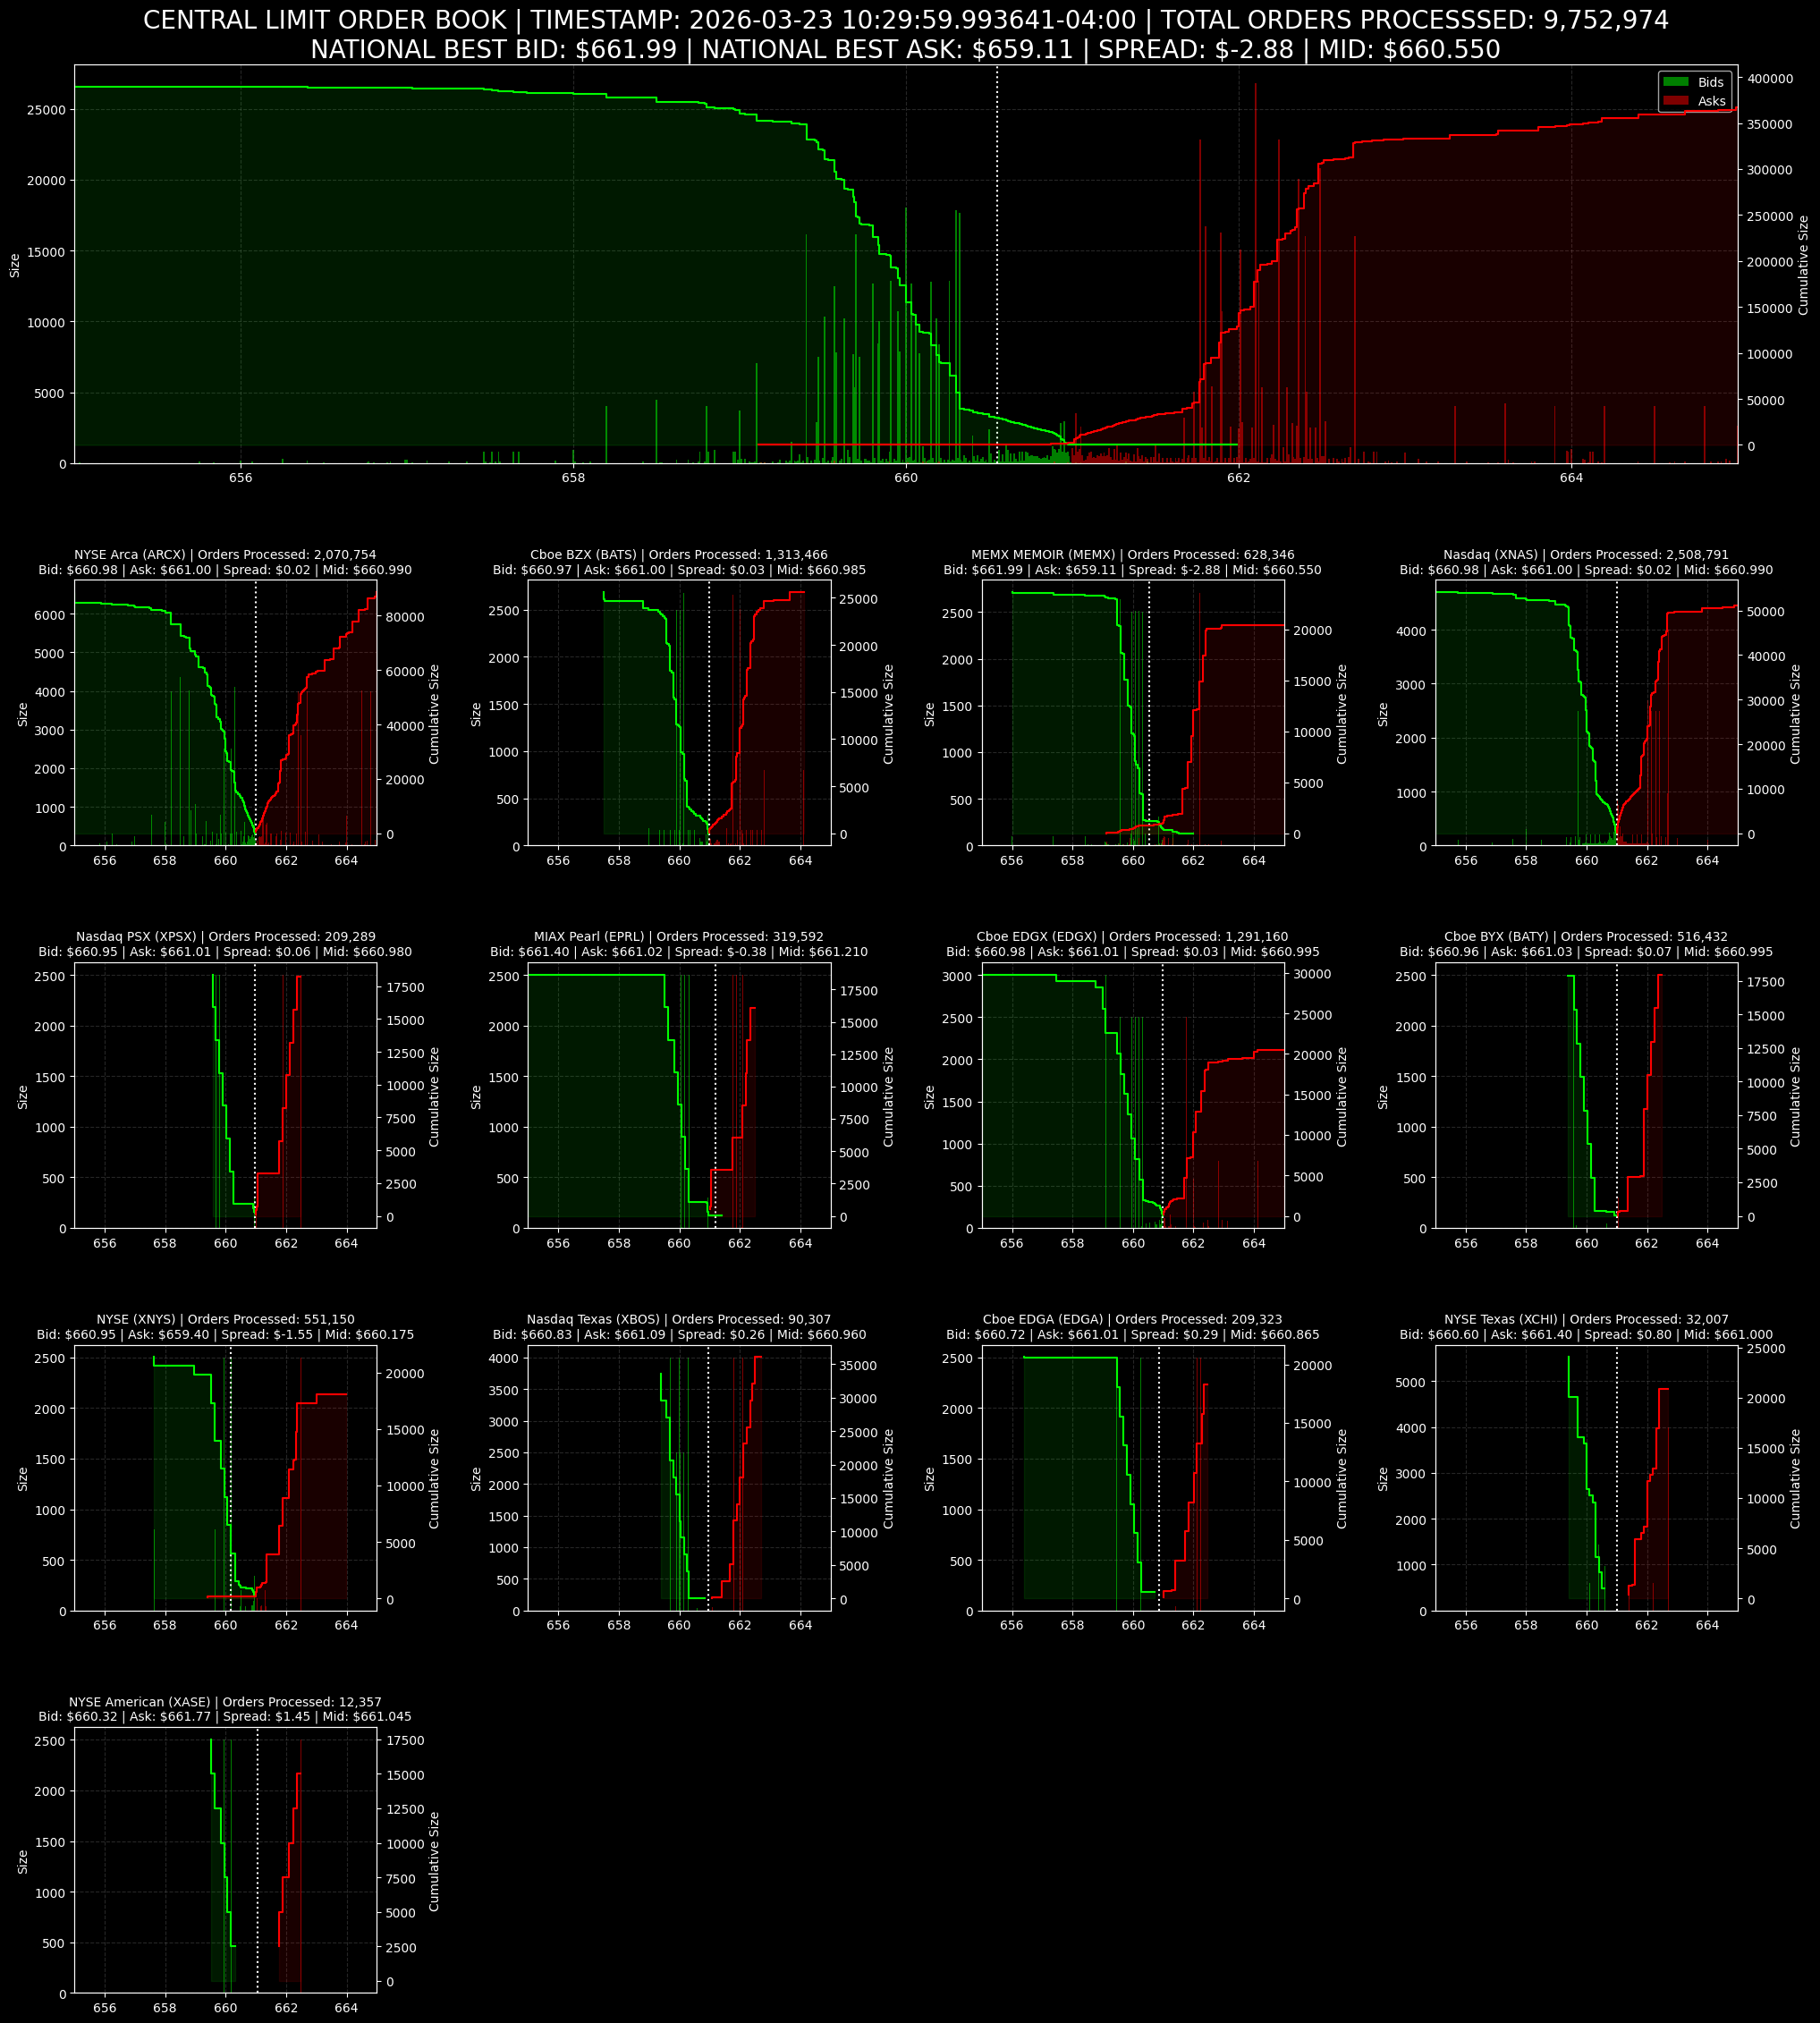

In [6]:
#######################################################################################################################################
#                                                                                                                                     #
#                                   HISTORICAL REPLAY OF LIMIT ORDER BOOK STARTS HERE                                                 #
#                                                                                                                                     #
#######################################################################################################################################

####################### SETUP SUBPLOTS USED TO DISPLAY LIMIT ORDER BOOKS ############################## 
#                                                                                                     #
#                                                                                                     #
#                                                                                                     #
#                                                                                                     #
#                                                                                                     # 
####################### SETUP SUBPLOTS USED TO DISPLAY LIMIT ORDER BOOKS ##############################

# setup grid layout for displaying all 14 limit order books and a central limit order book consolidating data from all exchanges
cols = 4
rows = int(np.ceil(len(publisher_id_list) / cols))

plt.style.use('dark_background')
fig = plt.figure(figsize=(24, 8 + 5 * rows))

# increase white space so right-side labels don't overlap with the next column
gs = gridspec.GridSpec(rows + 1, cols, figure=fig, height_ratios=[1.5] + [1]*rows, hspace=0.4, wspace=0.5)

# create the massive central limit order book at the top
ax_main = fig.add_subplot(gs[0, :])
ax2_main = ax_main.twinx()

# create the individual limit order books
axes = []
twin_axes = []
for i in range(rows):
    for j in range(cols):
        ax = fig.add_subplot(gs[i+1, j])
        axes.append(ax)
        twin_axes.append(ax.twinx())

order_processed_total = 0   # total number of orders processed
update_frequency = 1000000     # redraw the charts every 1,000,000 orders

########################### BEGIN LOOPING THORUGH MARKET BY ORDER DATA ################################ 
#                                                                                                     #
#                                                                                                     #
#                                                                                                     #
#                                                                                                     #
#                                                                                                     # 
########################## BEGIN LOOPING THORUGH MARKET BY ORDER DATA #################################

for order in market_by_order_data_df.itertuples():
    # ensure that a global id is created for each individual exchange so order_id from different exchanges do not conflict in the central limit order book
    global_id = f"{order.publisher_id}_{order.order_id}"

    # track the number of orders that have been processed 
    order_processed_total += 1
    order_processed_map[order.publisher_id] += 1

    ############################ MATCHING ENGINE LOGIC ####################################
    #                                                                                     #
    #                                                                                     #
    #                                                                                     #
    ############################ MATCHING ENGINE LOGIC ####################################

    # add a limit order to the limit order book 
    # a new order_id is created whenever a limit order is added to the limit order book 
    if order.action == 'A':
        if global_id not in order_tracker and order.side in ['A', 'B'] and order.price > 0:
            order_tracker[global_id] = {'publisher_id': order.publisher_id, 'order_side': order.side, 'order_price': order.price}
            book = asks[order.publisher_id] if order.side == 'A' else bids[order.publisher_id]
            if order.price not in book:
                book[order.price] = []
            book[order.price].append([global_id, order.size])
    
    # modify a limit order that is already in the limit order book
    # the order_id is used to track and modify the limit order that already exists in the limit order book 
    elif order.action == 'M':
        if global_id not in order_tracker: 
            if order.size > 0 and order.side in ['A', 'B'] and order.price > 0:
                order_tracker[global_id] = {'publisher_id': order.publisher_id, 'order_side': order.side, 'order_price': order.price}
                book = asks[order.publisher_id] if order.side == 'A' else bids[order.publisher_id]
                if order.price not in book:
                    book[order.price] = []
                book[order.price].append([global_id, order.size])
        else:
            old_order_price = order_tracker[global_id]['order_price']
            old_order_side = order_tracker[global_id]['order_side']
            book = asks[order.publisher_id] if old_order_side == 'A' else bids[order.publisher_id]

            new_order_price = order.price if order.price > 0 else old_order_price

            if order.size == 0:
                if old_order_price in book:
                    for i, o in enumerate(book[old_order_price]):
                        if o[0] == global_id:
                            book[old_order_price].pop(i)
                            if len(book[old_order_price]) == 0:
                                del book[old_order_price]
                            break
                del order_tracker[global_id]

            elif old_order_price != new_order_price:
                if old_order_price in book:
                    for i, o in enumerate(book[old_order_price]):
                        if o[0] == global_id:
                            book[old_order_price].pop(i)
                            if len(book[old_order_price]) == 0:
                                del book[old_order_price]
                            break
                
                if new_order_price not in book:
                    book[new_order_price] = []
                book[new_order_price].append([global_id, order.size])
                order_tracker[global_id]['order_price'] = new_order_price

            else:
                if old_order_price in book:
                    for o in book[old_order_price]:
                        if o[0] == global_id:
                            o[1] = order.size
                            break

    # cancel a limit order that is already in the limit order book 
    # the order_id is used to track and cancel the limit order that already exists in the limit order book
    elif order.action == 'C':
        if global_id in order_tracker:
            order_to_cancel_price = order_tracker[global_id]['order_price']
            order_to_cancel_side = order_tracker[global_id]['order_side']
            book = asks[order.publisher_id] if order_to_cancel_side == 'A' else bids[order.publisher_id]

            if order_to_cancel_price in book:
                for i, o in enumerate(book[order_to_cancel_price]):
                    if o[0] == global_id:
                        if order.size > 0 and order.size < o[1]:
                            o[1] -= order.size
                        else:
                            book[order_to_cancel_price].pop(i)
                            if len(book[order_to_cancel_price]) == 0:
                                del book[order_to_cancel_price]
                            del order_tracker[global_id]
                        break

    # restart limit order book and completely wipe out all limit order books
    # this happens after a circuit breaker where exchanges cancel all limit orders and introduce a call market to allow for new price discovery after large price moves
    elif order.action == 'R':
        bids[order.publisher_id].clear()
        asks[order.publisher_id].clear()
        # remove all limit orders in the exchange that restarted their limit order book
        # keep the limit orders in all the other exchanges
        order_tracker = {k: v for k, v in order_tracker.items() if v['publisher_id'] != order.publisher_id}

    ############################### GRAPHICS START HERE ###################################
    #                                                                                     #
    #                                                                                     #
    #                                                                                     #
    ############################### GRAPHICS START HERE ###################################       

    # graph and redraw the limit order book after a certain number of orders are processed OR if the end of the reconstruction window has been reached
    if order_processed_total % update_frequency == 0 or order_processed_total == len(market_by_order_data_df):
        ################## CONSOLIDATE 14 INDIVIDUAL LOB INTO ONE CLOB ########################
        #                                                                                     #
        #                                                                                     #
        #                                                                                     #
        ################## CONSOLIDATE 14 INDIVIDUAL LOB INTO ONE CLOB ########################      
        national_bids = {}
        national_asks = {}

        for publisher_id in publisher_id_list:
            for p, order_list in bids[publisher_id].items():
                volume_at_price = sum(x[1] for x in order_list)
                if volume_at_price > 0:
                    national_bids[p] = national_bids.get(p, 0) + volume_at_price
            for p, order_list in asks[publisher_id].items():
                volume_at_price = sum(x[1] for x in order_list)
                if volume_at_price > 0:
                    national_asks[p] = national_asks.get(p, 0) + volume_at_price

        national_bid_prices = np.array(list(national_bids.keys()))
        national_bid_volumes = np.array(list(national_bids.values()))
        national_ask_prices = np.array(list(national_asks.keys()))
        national_ask_volumes = np.array(list(national_asks.values()))

        national_bid_sort_idx = np.argsort(national_bid_prices)[::-1]
        national_bid_prices = national_bid_prices[national_bid_sort_idx]
        national_bid_volumes = national_bid_volumes[national_bid_sort_idx]

        national_ask_sort_idx = np.argsort(national_ask_prices)
        national_ask_prices = national_ask_prices[national_ask_sort_idx]
        national_ask_volumes = national_ask_volumes[national_ask_sort_idx]

        # if there are no bids across all 14 equity exchanges then the highest price a stock can be sold for is 0 dollars
        national_best_bid_price = national_bid_prices[0] if len(national_bid_prices) > 0 else 0
        # if there are no asks across all 14 equity exchanges then the lowest price a stock can be bought for is infinite dollars
        national_best_ask_price = national_ask_prices[0] if len(national_ask_prices) > 0 else 1e9

        national_mid_price = (national_best_bid_price + national_best_ask_price) / 2
        national_spread = national_best_ask_price - national_best_bid_price 

        ####################### GRAPH THE CENTRAL LIMIT ORDER BOOK ############################
        #                                                                                     #
        #                                                                                     #
        #                                                                                     #
        ####################### GRAPH THE CENTRAL LIMIT ORDER BOOK ############################    
        ax_main.cla()
        ax2_main.cla()

        if len(national_bid_prices) > 0 and len(national_ask_prices) > 0:
            # set up a fixed range of prices for x-axis of limit order book histogram
            fixed_min_price = 655.00
            fixed_max_price = 665.00

            national_bid_mask = national_bid_prices >= fixed_min_price
            national_ask_mask = national_ask_prices <= fixed_max_price

            # frequency histogram of bids and asks at each price
            ax_main.bar(national_bid_prices[national_bid_mask], national_bid_volumes[national_bid_mask], color='#00FF00', label='Bids', alpha=0.5, width=0.01)
            ax_main.bar(national_ask_prices[national_ask_mask], national_ask_volumes[national_ask_mask], color='#FF0000', label='Asks', alpha=0.5, width=0.01)

            # cumulative frequency histogram of bids at each price
            ax2_main.step(national_bid_prices[national_bid_mask], np.cumsum(national_bid_volumes[national_bid_mask]), color='#00FF00', where='post')
            ax2_main.fill_between(national_bid_prices[national_bid_mask], np.cumsum(national_bid_volumes[national_bid_mask]), color='#00FF00', step='post', alpha=0.1)

            # cumulative frequency histogram of asks at each price
            ax2_main.step(national_ask_prices[national_ask_mask], np.cumsum(national_ask_volumes[national_ask_mask]), color='#FF0000', where='pre')
            ax2_main.fill_between(national_ask_prices[national_ask_mask], np.cumsum(national_ask_volumes[national_ask_mask]), color='#FF0000', step='pre', alpha=0.1)

            # national mid price
            ax_main.axvline(national_mid_price, color='white', linestyle=':')
        
        # only display values within the fixed range of prices [fixed_min_price, fixed_max_price]
        ax_main.set_xlim(fixed_min_price, fixed_max_price)
        ax_main.grid(color='gray', linestyle='--', alpha=0.3)
        ax_main.legend(loc='upper right')

        # the national volume for bids and asks
        ax_main.set_ylabel('Size')
        ax_main.yaxis.tick_left()
        ax_main.yaxis.set_label_position('left')

        # the cumulative volume for bids and asks
        ax2_main.set_ylabel('Cumulative Size')
        ax2_main.yaxis.tick_right()
        ax2_main.yaxis.set_label_position('right')

        ax_main.set_title(
            f"CENTRAL LIMIT ORDER BOOK | TIMESTAMP: {order.ts_event} | TOTAL ORDERS PROCESSSED: {order_processed_total:,}\n"
            f"NATIONAL BEST BID: \${national_best_bid_price:.2f} | NATIONAL BEST ASK: \${national_best_ask_price:.2f} | SPREAD: \${national_spread:.2f} | MID: \${national_mid_price:.3f}",
            fontsize=20
        )

        ###################### GRAPH THE INDIVIDUAL LIMIT ORDER BOOKS #########################
        #                                                                                     #
        #                                                                                     #
        #                                                                                     #
        ###################### GRAPH THE INDIVIDUAL LIMIT ORDER BOOKS #########################   
        for idx, publisher_id in enumerate(publisher_id_list):
            ax = axes[idx]
            ax2 = twin_axes[idx]

            ax.cla()
            ax2.cla()

            # get the set of bids and asks for the individual exchange
            exchange_bids = bids[publisher_id]
            exchange_asks = asks[publisher_id]
            exchange_name = exchange_mapping[publisher_id]
            exchange_order_processed_total = order_processed_map[publisher_id]

            # if the limit order book of an individual exchange is empty, then state it is empty in the title and continue to the next limit order book without graphing anything
            if len(exchange_bids) == 0 or len(exchange_asks) == 0:
                ax.set_title(f"{exchange_name} | Orders: {exchange_order_processed_total:,} | LIMIT ORDER BOOK EMPTY", fontsize=10)
                ax.axis('off')
                ax2.axis('off')
                continue

            # the limit order book of an individual exchange contains a set of bids or a set of asks (it is nonempty)
            # run the same aggregation algorithm as the one for central limit order book, sorting bid and ask prices and extracting the best bid price, best bid size, best ask price, and best ask size
            
            exchange_bid_prices = np.array(list(exchange_bids.keys()))
            exchange_bid_volumes = np.array([sum(size for _, size in exchange_bids[p]) for p in exchange_bid_prices])

            exchange_ask_prices = np.array(list(exchange_asks.keys()))
            exchange_ask_volumes = np.array([sum(size for _, size in exchange_asks[p]) for p in exchange_ask_prices])

            exchange_bid_sort_idx = np.argsort(exchange_bid_prices)[::-1]
            exchange_bid_prices = exchange_bid_prices[exchange_bid_sort_idx]
            exchange_bid_volumes = exchange_bid_volumes[exchange_bid_sort_idx]

            exchange_ask_sort_idx = np.argsort(exchange_ask_prices)
            exchange_ask_prices = exchange_ask_prices[exchange_ask_sort_idx]
            exchange_ask_volumes = exchange_ask_volumes[exchange_ask_sort_idx]

            exchange_best_bid = exchange_bid_prices[0] if len(exchange_bid_prices) > 0 else 0
            exchange_best_ask = exchange_ask_prices[0] if len(exchange_ask_prices) > 0 else 1e9
            exchange_spread = exchange_best_ask - exchange_best_bid
            exchange_mid_price = (exchange_best_bid + exchange_best_ask) / 2

            exchange_bid_mask = exchange_bid_prices >= fixed_min_price
            exchange_ask_mask = exchange_ask_prices <= fixed_max_price

            ax.bar(exchange_bid_prices[exchange_bid_mask], exchange_bid_volumes[exchange_bid_mask], color='#00FF00', alpha=0.5, width=0.01)
            ax.bar(exchange_ask_prices[exchange_ask_mask], exchange_ask_volumes[exchange_ask_mask], color='#FF0000', alpha=0.5, width=0.01)

            ax2.step(exchange_bid_prices[exchange_bid_mask], np.cumsum(exchange_bid_volumes[exchange_bid_mask]), color='#00FF00', where='post')
            ax2.fill_between(exchange_bid_prices[exchange_bid_mask], np.cumsum(exchange_bid_volumes[exchange_bid_mask]), color='#00FF00', step='post', alpha=0.1)

            ax2.step(exchange_ask_prices[exchange_ask_mask], np.cumsum(exchange_ask_volumes[exchange_ask_mask]), color='#FF0000', where='pre')
            ax2.fill_between(exchange_ask_prices[exchange_ask_mask], np.cumsum(exchange_ask_volumes[exchange_ask_mask]), color='#FF0000', step='pre', alpha=0.1)

            ax.axvline(exchange_mid_price, color='white', linestyle=':')

            ax.set_title(
                f"{exchange_name} | Orders Processed: {exchange_order_processed_total:,}\n"
                f"Bid: \${exchange_best_bid:.2f} | Ask: \${exchange_best_ask:.2f} | Spread: \${exchange_spread:.2f} | Mid: \${exchange_mid_price:.3f}",
                fontsize=10
            )

            ax.grid(color='gray', linestyle='--', alpha=0.3)
            ax.set_xlim(fixed_min_price, fixed_max_price)

            ax.set_ylabel('Size')
            ax.yaxis.tick_left()
            ax.yaxis.set_label_position('left')

            ax2.set_ylabel('Cumulative Size')
            ax2.yaxis.tick_right()
            ax2.yaxis.set_label_position('right')

        # hide any unused subplots
        for idx in range(len(publisher_id_list), len(axes)):
            axes[idx].cla()
            axes[idx].axis('off')
            twin_axes[idx].cla()
            twin_axes[idx].cla()
            twin_axes[idx].axis('off')
        
        plt.tight_layout()

        clear_output(wait=True)
        display(fig)

plt.close()